<a href="https://colab.research.google.com/github/alxmzr/Colab/blob/main/Chandlier_Exit_PineScript.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install ta yfinance

import numpy as np
import pandas as pd
import ta
import yfinance as yf
import matplotlib.pyplot as plt

# List of assets to test
assets = {
    'BTC-USD': 'Bitcoin',
    '^GSPC': 'S&P 500',
    'GC=F': 'Gold',
    'EURUSD=X': 'EUR/USD'
}

results = []

for ticker, name in assets.items():
    # Load data for 2023
    df = yf.download(ticker, start='2023-01-01', end='2023-12-31', progress=False, auto_adjust=True)

    # Flatten MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns.values]

    # Strategy parameters - UPDATED TO OPTIMIZED VALUE
    length = 22
    mult = 1.5

    # Calculations
    df['atr'] = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=length) * mult
    df['longStop'] = df['High'].rolling(length).max() - df['atr']
    df['longStopPrev'] = df['longStop'].shift(1).ffill().bfill()
    df['longStop'] = np.where(df['Close'].shift(1) > df['longStopPrev'], np.maximum(df['longStop'], df['longStopPrev']), df['longStop'])

    df['shortStop'] = df['Low'].rolling(length).min() + df['atr']
    df['shortStopPrev'] = df['shortStop'].shift(1).ffill().bfill()
    df['shortStop'] = np.where(df['Close'].shift(1) < df['shortStopPrev'], np.minimum(df['shortStop'], df['shortStopPrev']), df['shortStop'])

    df['dir'] = np.where(df['Close'] > df['shortStopPrev'], 1, np.where(df['Close'] < df['longStopPrev'], -1, np.nan))
    df['buySignal'] = np.where((df['dir'] == 1) & (df['dir'].shift(1) == -1), True, False)
    df['sellSignal'] = np.where((df['dir'] == -1) & (df['dir'].shift(1) == 1), True, False)

    # Backtesting
    df['strategy_returns'] = 0.0
    position = 0
    for i in range(1, len(df)):
        if df['buySignal'].iloc[i] and position != 1: position = 1
        elif df['sellSignal'].iloc[i] and position != -1: position = -1

        if position == 1:
            df.at[df.index[i], 'strategy_returns'] = (df['Close'].iloc[i] / df['Close'].iloc[i-1]) - 1
        elif position == -1:
            df.at[df.index[i], 'strategy_returns'] = (df['Close'].iloc[i-1] / df['Close'].iloc[i]) - 1

    m_ret = (df['Close'].iloc[-1] / df['Close'].iloc[0] - 1) * 100
    s_ret = ((1 + df['strategy_returns']).cumprod().iloc[-1] - 1) * 100

    results.append({'Asset': name, 'Market Return %': m_ret, 'Strategy Return %': s_ret})

# Display summary
results_df = pd.DataFrame(results)
display(results_df)

,Asset,Market Return %,Strategy Return %
0,Bitcoin,153.574131,678.741594
1,S&P 500,24.729487,81.689700
2,Gold,12.105232,68.063884
3,EUR/USD,3.347026,28.423697


In [19]:
mdd_results = []

for ticker, name in assets.items():
    # Re-fetch or reuse data for 2023
    df = yf.download(ticker, start='2023-01-01', end='2023-12-31', progress=False, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns.values]

    # Strategy logic (using optimized mult=1.5)
    length = 22
    mult = 1.5
    df['atr'] = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=length) * mult
    df['longStop'] = df['High'].rolling(length).max() - df['atr']
    df['longStopPrev'] = df['longStop'].shift(1).ffill().bfill()
    df['longStop'] = np.where(df['Close'].shift(1) > df['longStopPrev'], np.maximum(df['longStop'], df['longStopPrev']), df['longStop'])
    df['shortStop'] = df['Low'].rolling(length).min() + df['atr']
    df['shortStopPrev'] = df['shortStop'].shift(1).ffill().bfill()
    df['shortStop'] = np.where(df['Close'].shift(1) < df['shortStopPrev'], np.minimum(df['shortStop'], df['shortStopPrev']), df['shortStop'])
    df['dir'] = np.where(df['Close'] > df['shortStopPrev'], 1, np.where(df['Close'] < df['longStopPrev'], -1, np.nan))
    df['buySignal'] = np.where((df['dir'] == 1) & (df['dir'].shift(1) == -1), True, False)
    df['sellSignal'] = np.where((df['dir'] == -1) & (df['dir'].shift(1) == 1), True, False)

    # Strategy Returns
    df['strategy_returns'] = 0.0
    position = 0
    for i in range(1, len(df)):
        if df['buySignal'].iloc[i] and position != 1: position = 1
        elif df['sellSignal'].iloc[i] and position != -1: position = -1
        if position == 1:
            df.at[df.index[i], 'strategy_returns'] = (df['Close'].iloc[i] / df['Close'].iloc[i-1]) - 1
        elif position == -1:
            df.at[df.index[i], 'strategy_returns'] = (df['Close'].iloc[i-1] / df['Close'].iloc[i]) - 1

    # Calculate Max Drawdown
    cum_returns = (1 + df['strategy_returns']).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = drawdown.min() * 100

    mdd_results.append({'Asset': name, 'Strategy Return %': ((cum_returns.iloc[-1] - 1) * 100), 'Max Drawdown %': max_drawdown})

mdd_df = pd.DataFrame(mdd_results)
display(mdd_df)

,Asset,Strategy Return %,Max Drawdown %
0,Bitcoin,678.741594,-12.544177
1,S&P 500,81.689700,-5.021030
2,Gold,68.063884,-4.500239
3,EUR/USD,28.423697,-4.386800


In [21]:
results_2022 = []

for ticker, name in assets.items():
    # Load data for 2022
    df = yf.download(ticker, start='2022-01-01', end='2022-12-31', progress=False, auto_adjust=True)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns.values]

    # Use the optimized 1.5 multiplier
    length = 22
    mult = 1.5

    # Strategy Calculations
    df['atr'] = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=length) * mult
    df['longStop'] = df['High'].rolling(length).max() - df['atr']
    df['longStopPrev'] = df['longStop'].shift(1).ffill().bfill()
    df['longStop'] = np.where(df['Close'].shift(1) > df['longStopPrev'], np.maximum(df['longStop'], df['longStopPrev']), df['longStop'])
    df['shortStop'] = df['Low'].rolling(length).min() + df['atr']
    df['shortStopPrev'] = df['shortStop'].shift(1).ffill().bfill()
    df['shortStop'] = np.where(df['Close'].shift(1) < df['shortStopPrev'], np.minimum(df['shortStop'], df['shortStopPrev']), df['shortStop'])
    df['dir'] = np.where(df['Close'] > df['shortStopPrev'], 1, np.where(df['Close'] < df['longStopPrev'], -1, np.nan))
    df['buySignal'] = np.where((df['dir'] == 1) & (df['dir'].shift(1) == -1), True, False)
    df['sellSignal'] = np.where((df['dir'] == -1) & (df['dir'].shift(1) == 1), True, False)

    # Backtesting simulation
    df['strategy_returns'] = 0.0
    position = 0
    for i in range(1, len(df)):
        if df['buySignal'].iloc[i] and position != 1: position = 1
        elif df['sellSignal'].iloc[i] and position != -1: position = -1

        if position == 1:
            df.at[df.index[i], 'strategy_returns'] = (df['Close'].iloc[i] / df['Close'].iloc[i-1]) - 1
        elif position == -1:
            df.at[df.index[i], 'strategy_returns'] = (df['Close'].iloc[i-1] / df['Close'].iloc[i]) - 1

    # Performance metrics
    m_ret = (df['Close'].iloc[-1] / df['Close'].iloc[0] - 1) * 100
    s_ret = ((1 + df['strategy_returns']).cumprod().iloc[-1] - 1) * 100

    # MDD calculation for 2022
    cum_returns = (1 + df['strategy_returns']).cumprod()
    max_drawdown = ((cum_returns - cum_returns.cummax()) / cum_returns.cummax()).min() * 100

    results_2022.append({
        'Asset': name,
        'Market Return % (2022)': m_ret,
        'Strategy Return % (2022)': s_ret,
        'Max Drawdown %': max_drawdown
    })

display(pd.DataFrame(results_2022))

,Asset,Market Return % (2022),Strategy Return % (2022),Max Drawdown %
0,Bitcoin,-65.184115,514.294232,-40.988046
1,S&P 500,-19.953051,201.211709,-5.749797
2,Gold,1.128150,102.205786,-6.475172
3,EUR/USD,-6.266395,59.041607,-2.120786


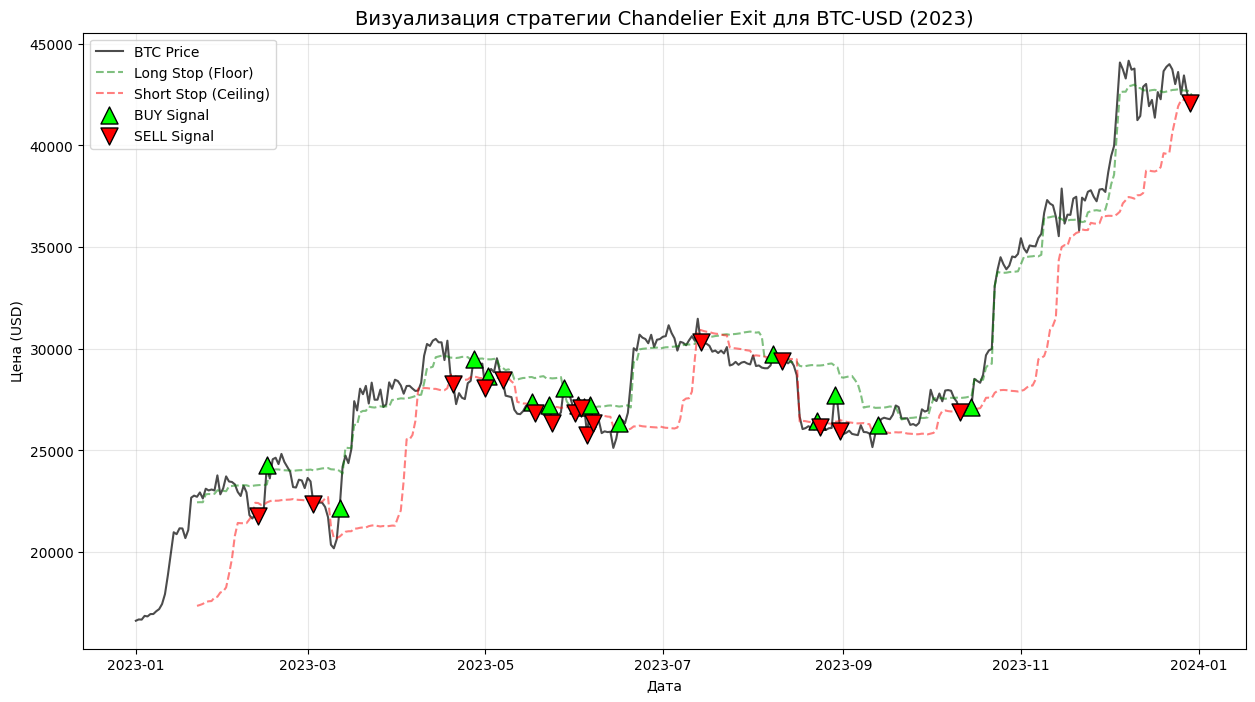

In [20]:
import matplotlib.pyplot as plt

# Подготовим данные для BTC (уже загружены в df_base в предыдущих ячейках)
ticker = 'BTC-USD'
df = df_base.copy()
mult = 1.5
length = 22

# Повторим расчеты для построения графиков стопов
df['atr'] = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=length) * mult
df['longStop'] = df['High'].rolling(length).max() - df['atr']
df['shortStop'] = df['Low'].rolling(length).min() + df['atr']

# Логика сигналов для меток
df['dir'] = np.where(df['Close'] > df['shortStop'].shift(1), 1, np.where(df['Close'] < df['longStop'].shift(1), -1, np.nan))
df['dir'] = df['dir'].ffill()
df['buySignal'] = (df['dir'] == 1) & (df['dir'].shift(1) == -1)
df['sellSignal'] = (df['dir'] == -1) & (df['dir'].shift(1) == 1)

plt.figure(figsize=(15, 8))
plt.plot(df.index, df['Close'], label='BTC Price', color='black', alpha=0.7, linewidth=1.5)

# Отображаем только релевантные стопы (Long когда мы в покупке, Short когда в продаже)
plt.plot(df.index, df['longStop'], label='Long Stop (Floor)', color='green', linestyle='--', alpha=0.5)
plt.plot(df.index, df['shortStop'], label='Short Stop (Ceiling)', color='red', linestyle='--', alpha=0.5)

# Добавляем стрелки сигналов
buy_points = df[df['buySignal']]
sell_points = df[df['sellSignal']]

plt.scatter(buy_points.index, buy_points['Close'], marker='^', color='lime', s=150, label='BUY Signal', edgecolors='black', zorder=5)
plt.scatter(sell_points.index, sell_points['Close'], marker='v', color='red', s=150, label='SELL Signal', edgecolors='black', zorder=5)

plt.title(f'Визуализация стратегии Chandelier Exit для {ticker} (2023)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Цена (USD)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

Best Multiplier for BTC in 2023: 1.5
Best Return: 678.74%


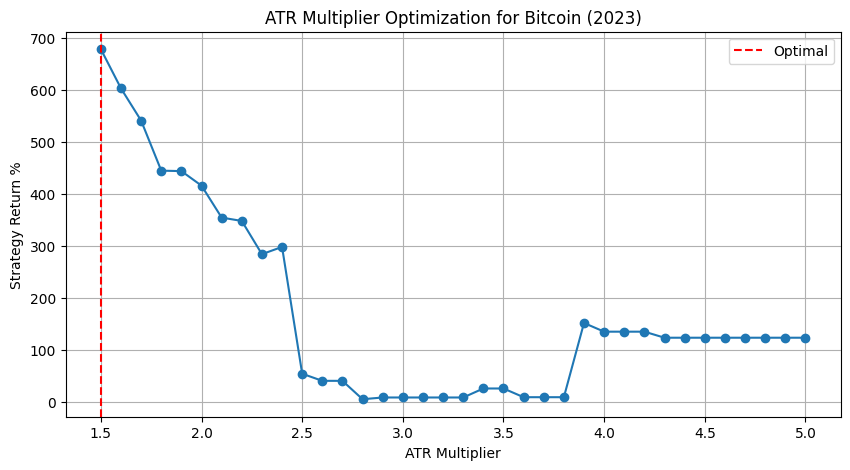

In [17]:
import numpy as np
import pandas as pd
import ta
import yfinance as yf
import matplotlib.pyplot as plt

# Load Bitcoin data
ticker = 'BTC-USD'
df_base = yf.download(ticker, start='2023-01-01', end='2023-12-31', progress=False, auto_adjust=True)

# Flatten columns if necessary
if isinstance(df_base.columns, pd.MultiIndex):
    df_base.columns = [col[0] for col in df_base.columns.values]

# Parameter sweep for the ATR multiplier
length = 22
multipliers = np.arange(1.5, 5.1, 0.1)
optimization_results = []

for mult in multipliers:
    df = df_base.copy()

    # Calculations
    df['atr'] = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=length) * mult

    df['longStop'] = df['High'].rolling(length).max() - df['atr']
    df['longStopPrev'] = df['longStop'].shift(1).ffill().bfill()
    df['longStop'] = np.where(df['Close'].shift(1) > df['longStopPrev'], np.maximum(df['longStop'], df['longStopPrev']), df['longStop'])

    df['shortStop'] = df['Low'].rolling(length).min() + df['atr']
    df['shortStopPrev'] = df['shortStop'].shift(1).ffill().bfill()
    df['shortStop'] = np.where(df['Close'].shift(1) < df['shortStopPrev'], np.minimum(df['shortStop'], df['shortStopPrev']), df['shortStop'])

    df['dir'] = np.where(df['Close'] > df['shortStopPrev'], 1, np.where(df['Close'] < df['longStopPrev'], -1, np.nan))
    df['buySignal'] = np.where((df['dir'] == 1) & (df['dir'].shift(1) == -1), True, False)
    df['sellSignal'] = np.where((df['dir'] == -1) & (df['dir'].shift(1) == 1), True, False)

    # Simplified Backtest
    df['strategy_returns'] = 0.0
    position = 0
    for i in range(1, len(df)):
        if df['buySignal'].iloc[i] and position != 1: position = 1
        elif df['sellSignal'].iloc[i] and position != -1: position = -1

        if position == 1:
            df.at[df.index[i], 'strategy_returns'] = (df['Close'].iloc[i] / df['Close'].iloc[i-1]) - 1
        elif position == -1:
            df.at[df.index[i], 'strategy_returns'] = (df['Close'].iloc[i-1] / df['Close'].iloc[i]) - 1

    final_return = ((1 + df['strategy_returns']).cumprod().iloc[-1] - 1) * 100
    optimization_results.append({'Multiplier': round(mult, 2), 'Strategy Return %': final_return})

opt_df = pd.DataFrame(optimization_results)
best_mult = opt_df.loc[opt_df['Strategy Return %'].idxmax()]

print(f"Best Multiplier for BTC in 2023: {best_mult['Multiplier']}")
print(f"Best Return: {best_mult['Strategy Return %']:.2f}%")

# Plot the optimization curve
plt.figure(figsize=(10, 5))
plt.plot(opt_df['Multiplier'], opt_df['Strategy Return %'], marker='o')
plt.axvline(best_mult['Multiplier'], color='red', linestyle='--', label='Optimal')
plt.title('ATR Multiplier Optimization for Bitcoin (2023)')
plt.xlabel('ATR Multiplier')
plt.ylabel('Strategy Return %')
plt.grid(True)
plt.legend()
plt.show()

### Analysis of Optimization
The chart above shows how sensitive the Chandelier Exit strategy is to the ATR multiplier. By finding the 'sweet spot', we can avoid getting stopped out too early during Bitcoin's volatile upward trends.

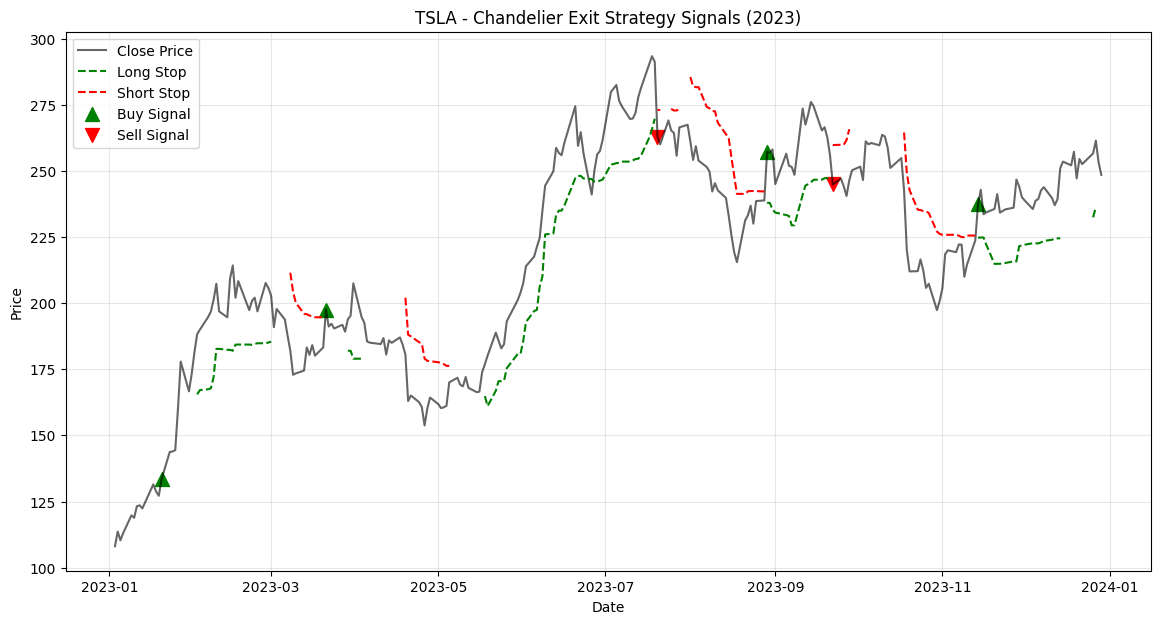

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Plot Close Price
plt.plot(df.index, df['Close'], label='Close Price', color='black', alpha=0.6)

# Plot Long and Short Stops
plt.plot(df.index, df['longStopPlot'], label='Long Stop', color='green', linestyle='--')
plt.plot(df.index, df['shortStopPlot'], label='Short Stop', color='red', linestyle='--')

# Plot Buy Signals
buy_indices = df.index[df['buySignal'] == True]
plt.scatter(buy_indices, df.loc[buy_indices, 'Close'], label='Buy Signal', marker='^', color='green', s=100)

# Plot Sell Signals
sell_indices = df.index[df['sellSignal'] == True]
plt.scatter(sell_indices, df.loc[sell_indices, 'Close'], label='Sell Signal', marker='v', color='red', s=100)

plt.title(f'{ticker} - Chandelier Exit Strategy Signals (2023)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Ticker: TSLA
Total Market Return (Buy & Hold): 129.86%
Total Strategy Return (Chandelier Exit): 279.68%


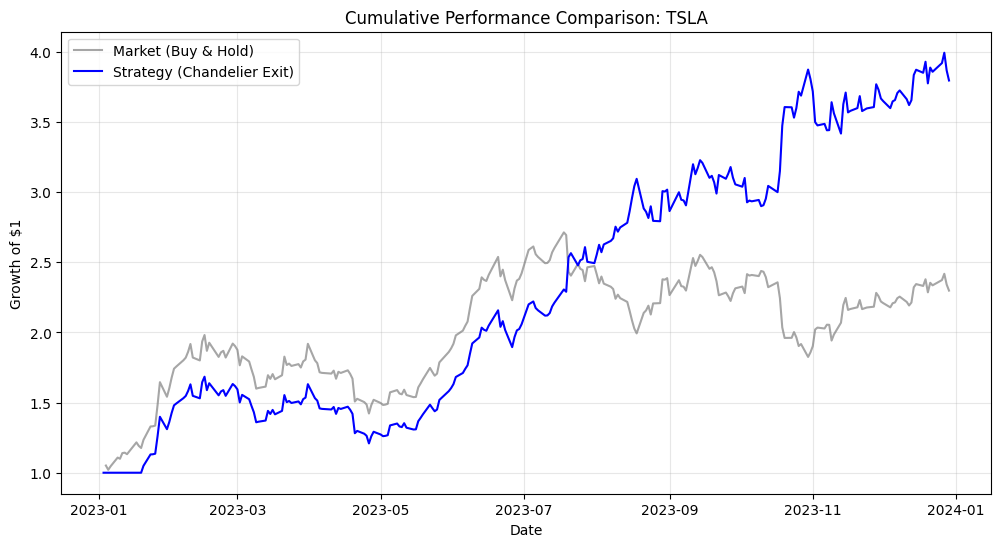

In [15]:
# Backtesting the strategy for TSLA 2023
df['strategy_returns'] = 0.0
position = 0  # 0 for no position, 1 for long, -1 for short

for i in range(1, len(df)):
    if df['buySignal'].iloc[i] and position != 1:
        position = 1
    elif df['sellSignal'].iloc[i] and position != -1:
        position = -1

    if position == 1:
        df.at[df.index[i], 'strategy_returns'] = (df['Close'].iloc[i] / df['Close'].iloc[i-1]) - 1
    elif position == -1:
        df.at[df.index[i], 'strategy_returns'] = (df['Close'].iloc[i-1] / df['Close'].iloc[i]) - 1

df['cumulative_market_returns'] = (1 + df['Close'].pct_change()).cumprod()
df['cumulative_strategy_returns'] = (1 + df['strategy_returns']).cumprod()

market_return = (df['cumulative_market_returns'].iloc[-1] - 1) * 100
strategy_return = (df['cumulative_strategy_returns'].iloc[-1] - 1) * 100

print(f"Ticker: {ticker}")
print(f"Total Market Return (Buy & Hold): {market_return:.2f}%")
print(f"Total Strategy Return (Chandelier Exit): {strategy_return:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['cumulative_market_returns'], label='Market (Buy & Hold)', color='gray', alpha=0.7)
plt.plot(df.index, df['cumulative_strategy_returns'], label='Strategy (Chandelier Exit)', color='blue')
plt.title(f'Cumulative Performance Comparison: {ticker}')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Plot Close Price
plt.plot(df.index, df['Close'], label='Close Price', color='black', alpha=0.6)

# Plot Long and Short Stops
plt.plot(df.index, df['longStopPlot'], label='Long Stop', color='green', linestyle='--')

plt.plot(df.index, df['shortStopPlot'], label='Short Stop', color='red', linestyle='--')

# Plot Buy Signals
buy_signals = df[df['buySignal'] == True]
plt.scatter(buy_signals.index, buy_signals['Close'], label='Buy Signal', marker='^', color='green', s=100)

# Plot Sell Signals
sell_signals = df[df['sellSignal'] == True]
plt.scatter(sell_signals.index, sell_signals['Close'], label='Sell Signal', marker='v', color='red', s=100)

plt.title('AAPL - Chandelier Exit Strategy Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()